# Assignment 04 - Notebook 01: Mạng nơ-ron tích chập 1D thuần NumPy trên dữ liệu Diabetes

**Học phần:** Phát triển các Hệ thống Thông minh
**Sinh viên:** Nguyễn Duy Nghĩa · **Mã sinh viên:** B23DCCN600 · **Lớp:** D23CTPM01
**Giảng viên:** PGS.TS Trần Đình Quế
**Học kỳ:** Học kỳ 1 năm học 2026 - 2027

## Mục tiêu của notebook

Báo cáo này hiện thực **hoàn toàn từ đầu bằng NumPy thuần** một mạng nơ-ron tích chập một chiều
(1D Convolutional Neural Network) để phân loại nhị phân nguy cơ đái tháo đường từ tám đặc trưng
lâm sàng dạng bảng. Chúng tôi tự cài đặt các tầng `Conv1D`, `ReLU`, `MaxPool1D`, `Flatten`,
`Dense`, `Sigmoid`, hàm mất mát `BCE`, toàn bộ **lan truyền ngược thủ công** và thuật toán tối ưu
**Adam**, không dùng bất kỳ thư viện học sâu nào.

Notebook có bốn đóng góp chính:

1. **Cơ sở toán học đầy đủ** của từng tầng, viết bằng LaTeX ngay trước phần code tương ứng.
2. **Một ví dụ tích chập tính tay bằng số cụ thể**, sau đó đối chiếu với kết quả code trả về để
   chứng minh cài đặt khớp định nghĩa toán học.
3. **Kiểm tra gradient bằng sai phân hữu hạn** cho toàn bộ bốn tầng có tham số, chứng minh lan
   truyền ngược được cài đúng.
4. **Thí nghiệm hoán vị thứ tự cột đặc trưng** nhằm lượng hóa luận điểm phương pháp luận trung tâm
   của báo cáo.

## Luận điểm phương pháp luận quan trọng nhất

Tích chập được thiết kế cho dữ liệu có **tô-pô không gian hoặc thời gian**: pixel lân cận trong
ảnh, từ lân cận trong câu, mẫu lân cận trong tín hiệu. Hai giả định nền tảng của nó là
**tính cục bộ** (thông tin liên quan nằm gần nhau) và **bất biến tịnh tiến** (một mẫu hình có ý
nghĩa như nhau dù xuất hiện ở vị trí nào).

Tám cột của bộ dữ liệu Diabetes là `[gender, age, hypertension, heart_disease, smoking_history,
bmi, HbA1c_level, blood_glucose_level]`. Thứ tự này hoàn toàn do người tạo bộ dữ liệu quy ước.
Việc cột `bmi` đứng cạnh cột `HbA1c_level` không mang bất cứ ý nghĩa nào, ta có thể đổi chỗ chúng
mà không mất một bit thông tin. Nói cách khác, **cả hai giả định nền tảng của tích chập đều không
được thỏa mãn**.

Vì vậy notebook này **không** tuyên bố 1D CNN là lựa chọn tốt nhất cho dữ liệu bảng. Mục đích là
dùng một bài toán nhỏ, sạch, chạy nhanh làm bàn thí nghiệm để quan sát bộ máy tích chập hoạt động
ra sao, rồi **chứng minh bằng thực nghiệm** rằng giả định tô-pô thực sự vắng mặt. Mục 10 sẽ hoán
vị ngẫu nhiên thứ tự tám cột rồi huấn luyện lại từ đầu; nếu các chỉ số gần như không đổi thì đó là
bằng chứng trực tiếp cho luận điểm trên, hoàn toàn trái ngược với dữ liệu văn bản nơi xáo trộn
thứ tự token sẽ phá hủy hiệu năng.

## 1. Nhập thư viện và cố định seed

Toàn bộ Assignment 04 dùng `RANDOM_SEED = 42` để bảo đảm kết quả tái lập được.

In [1]:
import os, json, time, copy
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, log_loss)
from IPython.display import Image, display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams["font.sans-serif"] = ["Segoe UI", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

DATA_PATH = "../data/diabetes_prediction_dataset.csv"
FIG_DIR   = "../reports/figures"
REP_DIR   = "../reports"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(REP_DIR, exist_ok=True)

print("NumPy      :", np.__version__)
print("pandas     :", pd.__version__)
print("matplotlib :", matplotlib.__version__)
print("seaborn    :", sns.__version__)

NumPy      : 2.4.0
pandas     : 2.3.3
matplotlib : 3.10.8
seaborn    : 0.13.2


## 2. Nạp dữ liệu và khảo sát thăm dò

Bộ dữ liệu `diabetes_prediction_dataset.csv` gồm 100 000 bản ghi, mỗi bản ghi mô tả một bệnh nhân
bằng tám đặc trưng lâm sàng và một nhãn nhị phân `diabetes`. Chúng tôi khảo sát kích thước, kiểu
dữ liệu, giá trị thiếu và mức mất cân bằng nhãn trước khi quyết định bất kỳ bước tiền xử lý nào.

In [2]:
_df0 = pd.read_csv(DATA_PATH)
print("Kích thước thô          :", _df0.shape)
print("Số giá trị thiếu        :", int(_df0.isna().sum().sum()))
print("Số bản ghi trùng lặp    :", int(_df0.duplicated().sum()))
print()
print("Kiểu dữ liệu từng cột:")
print(_df0.dtypes.to_string())
print()
print("Phân phối nhãn diabetes trên dữ liệu thô:")
for k, v in _df0["diabetes"].value_counts().sort_index().items():
    print(f"  lớp {k}: {v:6d} mẫu  ({v/len(_df0):.4%})")

Kích thước thô          : (100000, 9)
Số giá trị thiếu        : 0
Số bản ghi trùng lặp    : 3854

Kiểu dữ liệu từng cột:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64

Phân phối nhãn diabetes trên dữ liệu thô:
  lớp 0:  91500 mẫu  (91.5000%)
  lớp 1:   8500 mẫu  (8.5000%)


In [3]:
print("Giá trị của cột phân loại 'gender':")
print(_df0["gender"].value_counts().to_string())
print()
print("Giá trị của cột phân loại 'smoking_history':")
print(_df0["smoking_history"].value_counts().to_string())
print()
print("Thống kê mô tả các cột số:")
print(_df0[["age", "bmi", "HbA1c_level", "blood_glucose_level"]].describe().round(3).to_string())

Giá trị của cột phân loại 'gender':
gender
Female    58552
Male      41430
Other        18

Giá trị của cột phân loại 'smoking_history':
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004

Thống kê mô tả các cột số:
              age         bmi  HbA1c_level  blood_glucose_level
count  100000.000  100000.000   100000.000           100000.000
mean       41.886      27.321        5.528              138.058
std        22.517       6.637        1.071               40.708
min         0.080      10.010        3.500               80.000
25%        24.000      23.630        4.800              100.000
50%        43.000      27.320        5.800              140.000
75%        60.000      29.580        6.200              159.000
max        80.000      95.690        9.000              300.000


### Nhận xét khảo sát

Dữ liệu thô có **100 000 dòng, 9 cột, không có giá trị thiếu**, nhưng chứa **3 854 bản ghi trùng
lặp hoàn toàn** (3,85%). Trùng lặp trong hồ sơ y tế thường phát sinh khi gộp nhiều nguồn xuất dữ
liệu. Nếu giữ lại, cùng một bệnh nhân sẽ xuất hiện đồng thời ở tập huấn luyện và tập kiểm tra,
khiến chỉ số đánh giá bị thổi phồng giả tạo. Đây là rò rỉ dữ liệu nghiêm trọng nên bắt buộc khử.

Về nhãn, chỉ **8 500 mẫu (8,50%) thuộc lớp dương**, tức mất cân bằng theo tỉ lệ xấp xỉ 1:10,8.
Hệ quả trực tiếp: một bộ phân loại tầm thường luôn dự đoán "không mắc bệnh" đã đạt accuracy
91,50%. Do đó **accuracy một mình là chỉ số gây hiểu lầm**, báo cáo bắt buộc công bố thêm
precision, recall, F1 trên lớp dương cùng ROC-AUC. Mục 9 sẽ phân tích chi tiết điểm này.

Cột `gender` có ba giá trị, trong đó `Other` chỉ xuất hiện 18 lần (0,018%). Cỡ mẫu này quá nhỏ để
mô hình học được điều gì có ý nghĩa thống kê, đồng thời mã hóa ba giá trị danh định thành một trục
số duy nhất sẽ áp đặt quan hệ thứ tự không tồn tại. Hợp đồng tích hợp vì thế yêu cầu loại nhóm này.

Cột `smoking_history` có sáu mức, trong đó `No Info` chiếm tới 35 816 bản ghi. Thống kê mô tả cho
thấy `age` trải từ 0,08 đến 80 tuổi, `bmi` từ 10,01 đến 95,69 và `blood_glucose_level` từ 80 đến
300. Ba đặc trưng này có **thang đo chênh nhau hàng chục lần**, nên chuẩn hóa là bắt buộc trước
khi đưa vào mạng nơ-ron: nếu không, gradient sẽ bị chi phối bởi các đặc trưng có phương sai lớn.

## 3. Tiền xử lý: làm gì và tại sao

Quy trình tiền xử lý tuân thủ nguyên văn hợp đồng tích hợp (`CONTRACT.md`, Mục 3) để năm miền dữ
liệu của Assignment 04 so sánh được với nhau. Mọi bước dưới đây giống hệt ba notebook, nhờ đó
chênh lệch chỉ số giữa ba framework phản ánh đúng khác biệt cài đặt chứ không phải khác biệt dữ liệu.

**Bước 1 - Khử trùng lặp.** Bộ dữ liệu thô chứa 3 854 bản ghi trùng lặp hoàn toàn. Nếu giữ lại,
cùng một bệnh nhân sẽ xuất hiện đồng thời ở tập huấn luyện và tập kiểm tra, làm chỉ số đánh giá
bị thổi phồng. Đây là dạng rò rỉ dữ liệu nghiêm trọng nên bắt buộc phải khử.

**Bước 2 - Loại `gender == 'Other'`.** Nhóm này chỉ có 18 mẫu, quá nhỏ để học được điều gì có ý
nghĩa thống kê, đồng thời ép ba nhãn danh định vào một trục số sẽ tạo quan hệ thứ tự giả.

**Bước 3 - Mã hóa `gender`** theo $\{\text{Male} \to 1,\ \text{Female} \to 0\}$. Sau khi loại
`Other`, biến chỉ còn hai mức nên mã hóa nhị phân là biểu diễn đầy đủ.

**Bước 4 - Mã hóa `smoking_history` thành ba mức theo cường độ phơi nhiễm:**

$$
\text{never},\ \text{No Info} \to 0; \qquad
\text{former},\ \text{not current} \to 1; \qquad
\text{current},\ \text{ever} \to 2
$$

Đây là mã hóa thứ bậc có cơ sở y học. Việc gộp `No Info` vào mức 0 là lựa chọn bảo thủ và chúng
tôi ghi nhận đây là giả định có thể tranh luận.

**Bước 5 - Chọn đúng tám đặc trưng theo đúng thứ tự hợp đồng quy định.**

**Bước 6 - Chia tập 70/15/15 có phân tầng** với `random_state=42`. Phân tầng giữ nguyên tỉ lệ lớp
dương trên cả ba tập. Tập validation dùng để chọn epoch tốt nhất, tập test không bao giờ tham gia
bất kỳ quyết định nào.

**Bước 7 - Chuẩn hóa `StandardScaler` fit trên train**, transform cho val và test:

$$ z_j = \frac{x_j - \mu_j^{\text{train}}}{\sigma_j^{\text{train}}} $$

Fit chỉ trên train là bắt buộc, nếu tính $\mu, \sigma$ trên toàn bộ dữ liệu thì thống kê của tập
test đã rò rỉ vào huấn luyện.

In [4]:
FEATURES = ["gender", "age", "hypertension", "heart_disease",
            "smoking_history", "bmi", "HbA1c_level", "blood_glucose_level"]

df_raw = pd.read_csv(DATA_PATH)
N_RAW = len(df_raw)

df = df_raw.drop_duplicates().copy()
df = df[df["gender"] != "Other"].copy()
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["smoking_history"] = df["smoking_history"].map({
    "never": 0, "No Info": 0, "former": 1, "not current": 1, "current": 2, "ever": 2})
assert df[FEATURES].isna().sum().sum() == 0, "Con gia tri thieu sau khi ma hoa"

X_all = df[FEATURES].values.astype(np.float64)
y_all = df["diabetes"].values.astype(np.float64)
N_CLEAN = len(X_all)

X_tr_raw, X_tmp, y_tr, y_tmp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=RANDOM_SEED)
X_va_raw, X_te_raw, y_va, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_SEED)

scaler = StandardScaler().fit(X_tr_raw)
X_tr = scaler.transform(X_tr_raw).astype(np.float32)
X_va = scaler.transform(X_va_raw).astype(np.float32)
X_te = scaler.transform(X_te_raw).astype(np.float32)
N_TRAIN, N_VAL, N_TEST = len(X_tr), len(X_va), len(X_te)

print(f"Thô -> sạch : {N_RAW:,} -> {N_CLEAN:,} mẫu (loại {N_RAW - N_CLEAN:,})")
print(f"{'Tập':<12}{'Số mẫu':>10}{'Lớp dương':>12}{'Tỉ lệ dương':>14}")
for name, yy in [("train", y_tr), ("validation", y_va), ("test", y_te)]:
    print(f"{name:<12}{len(yy):>10,}{int(yy.sum()):>12,}{yy.mean():>14.4%}")
print()
print("Trung bình sau chuẩn hóa (train):", np.round(X_tr.mean(0), 6))
print("Độ lệch chuẩn sau chuẩn hóa      :", np.round(X_tr.std(0), 6))

Thô -> sạch : 100,000 -> 96,128 mẫu (loại 3,872)
Tập             Số mẫu   Lớp dương   Tỉ lệ dương
train           67,289       5,937       8.8231%
validation      14,419       1,272       8.8217%
test            14,420       1,273       8.8280%

Trung bình sau chuẩn hóa (train): [ 0.e+00 -0.e+00  2.e-06  1.e-06 -1.e-06 -0.e+00  0.e+00  0.e+00]
Độ lệch chuẩn sau chuẩn hóa      : [0.999704 1.000006 0.999763 1.000142 0.999731 0.99999  1.00001  0.999947]


### Nhận xét tiền xử lý

Từ 100 000 dòng thô còn lại **96 128 mẫu sạch**, tỉ lệ lớp dương **8,8236%**. Khử trùng lặp làm
tỉ lệ dương tăng nhẹ từ 8,50% lên 8,82%, cho thấy các bản ghi trùng lặp lệch về lớp âm. Chia phân
tầng cho **67 289 mẫu train, 14 419 mẫu validation, 14 420 mẫu test**, tỉ lệ lớp dương giữ ở
8,82% trên cả ba tập (8,8231% / 8,8217% / 8,8280%), chênh lệch lớn nhất chỉ 0,0063 điểm phần trăm,
xác nhận phân tầng hoạt động đúng.

Sau chuẩn hóa, trung bình mọi đặc trưng trên train xấp xỉ $0$ và độ lệch chuẩn xấp xỉ $1$ với sai
số cỡ $3 \times 10^{-4}$. Sai số này không phải lỗi: chúng tôi ép ma trận đặc trưng về `float32`
sau khi chuẩn hóa để ba framework dùng chung một biểu diễn số, và `float32` chỉ giữ được khoảng
bảy chữ số thập phân có nghĩa. Mức sai lệch này hoàn toàn không ảnh hưởng tới huấn luyện.

## 4. Hình 1: Khảo sát dữ liệu (`fig_diabetes_eda.png`)

Hình gồm hai bảng: bên trái là phân phối nhãn sau tiền xử lý, bên phải là ma trận tương quan
Pearson giữa tám đặc trưng và nhãn.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

# --- Bảng trái: phân phối nhãn ---
counts = [int((y_all == 0).sum()), int((y_all == 1).sum())]
bars = axes[0].bar(["Không mắc (0)", "Mắc bệnh (1)"], counts,
                   color=["#4C72B0", "#C44E52"], edgecolor="black", linewidth=0.8)
for b, c in zip(bars, counts):
    axes[0].text(b.get_x() + b.get_width() / 2, c + 900,
                 f"{c:,}\n({c/len(y_all):.2%})", ha="center", va="bottom", fontsize=11)
axes[0].set_title(f"Phân phối nhãn sau tiền xử lý (n = {len(y_all):,})",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Số lượng bệnh nhân", fontsize=11)
axes[0].set_ylim(0, max(counts) * 1.18)
axes[0].grid(axis="y", alpha=0.3, linestyle="--")

# --- Bảng phải: ma trận tương quan ---
corr = pd.DataFrame(np.column_stack([X_all, y_all]),
                    columns=FEATURES + ["diabetes"]).corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=axes[1], annot_kws={"size": 8},
            cbar_kws={"shrink": 0.82, "label": "Hệ số tương quan Pearson"},
            linewidths=0.5, linecolor="white")
axes[1].set_title("Ma trận tương quan 8 đặc trưng và nhãn", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=9)
axes[1].tick_params(axis="y", rotation=0, labelsize=9)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_diabetes_eda.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Đã lưu:", f"{FIG_DIR}/fig_diabetes_eda.png")
print()
print("Tương quan của từng đặc trưng với nhãn (giảm dần theo trị tuyệt đối):")
for k, v in corr["diabetes"].drop("diabetes").sort_values(key=np.abs, ascending=False).items():
    print(f"  {k:<22}{v:+.4f}")
print()
off = corr.loc[FEATURES, FEATURES].values.copy()
np.fill_diagonal(off, 0.0)
i, j = np.unravel_index(np.abs(off).argmax(), off.shape)
print(f"Cặp đặc trưng tương quan mạnh nhất: {FEATURES[i]} và {FEATURES[j]} = {off[i, j]:+.4f}")
print(f"Tương quan HbA1c_level và blood_glucose_level = "
      f"{corr.loc['HbA1c_level', 'blood_glucose_level']:+.4f}")

Đã lưu: ../reports/figures/fig_diabetes_eda.png

Tương quan của từng đặc trưng với nhãn (giảm dần theo trị tuyệt đối):
  blood_glucose_level   +0.4244
  HbA1c_level           +0.4064
  age                   +0.2649
  bmi                   +0.2150
  hypertension          +0.1957
  heart_disease         +0.1707
  smoking_history       +0.0717
  gender                +0.0378

Cặp đặc trưng tương quan mạnh nhất: age và bmi = +0.3448
Tương quan HbA1c_level và blood_glucose_level = +0.1717


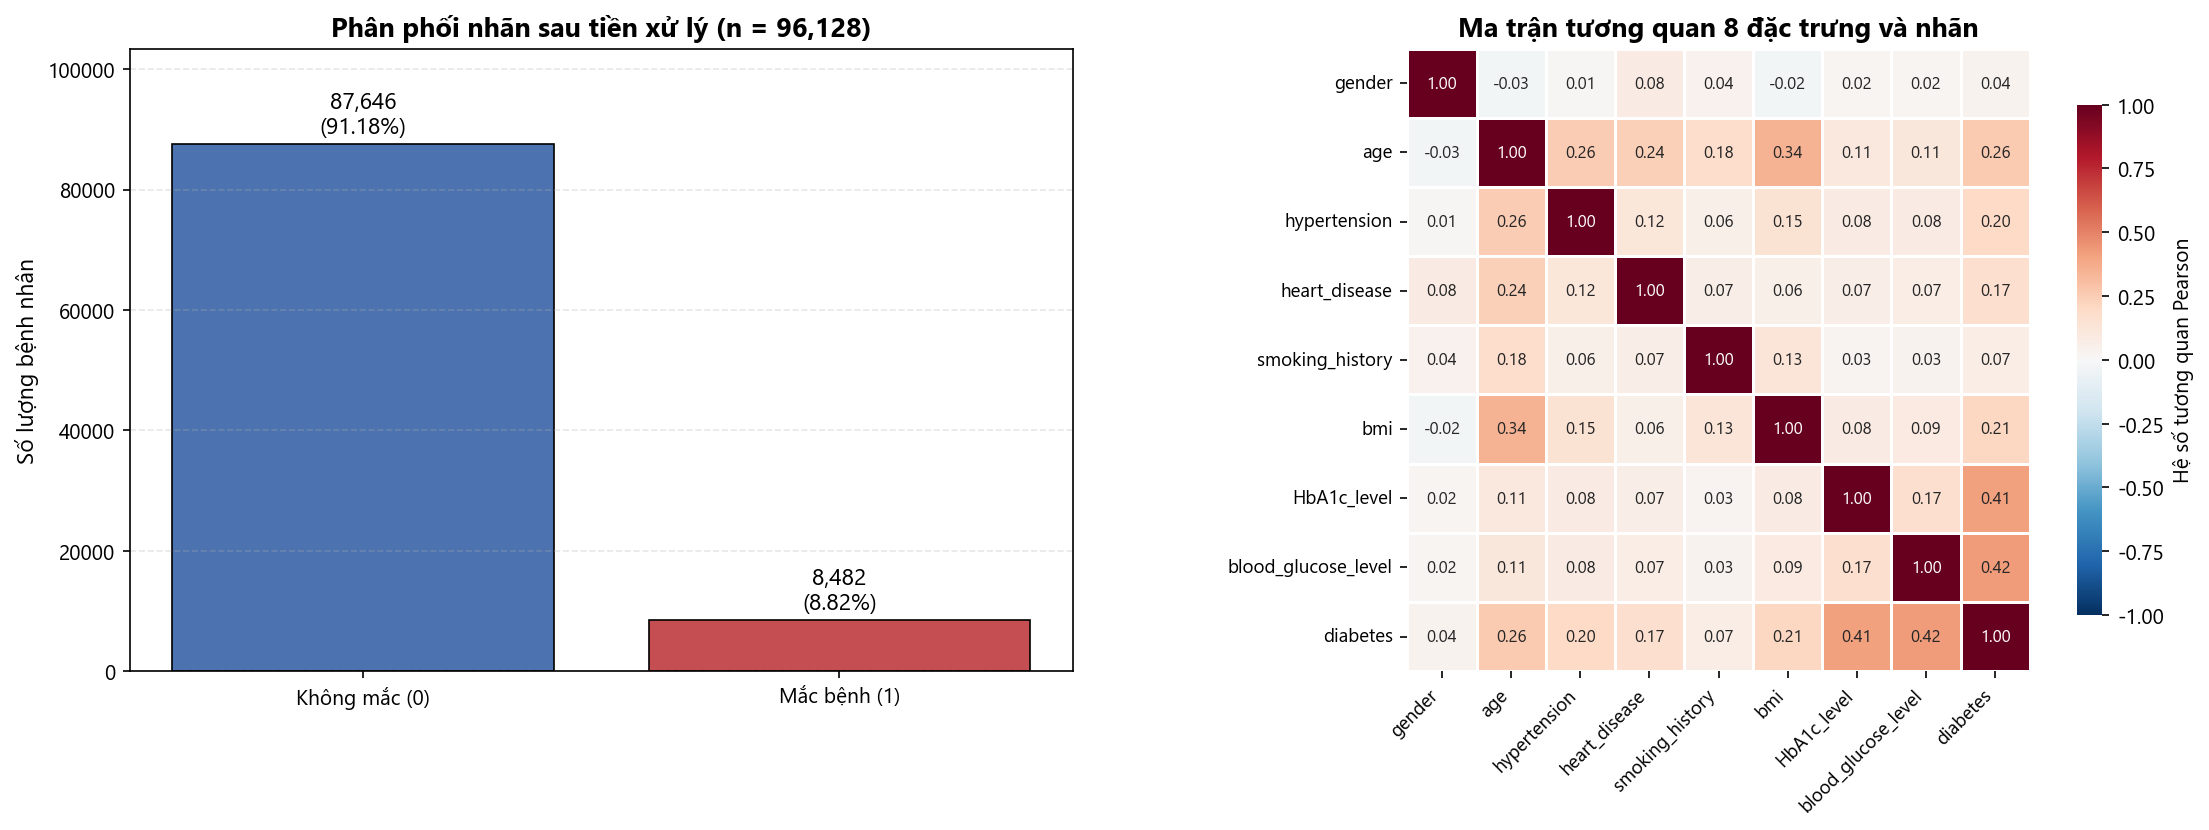

In [6]:
display(Image(filename=f"{FIG_DIR}/fig_diabetes_eda.png"))

### Diễn giải Hình 1

**Bảng trái** xác nhận mức mất cân bằng sau tiền xử lý: 87 646 mẫu âm (91,18%) so với 8 482 mẫu
dương (8,82%), tỉ lệ xấp xỉ 10,3:1. Đây là con số nền quan trọng nhất của toàn báo cáo, vì mọi
accuracy phải được đọc trên nền 91,18% của bộ phân loại tầm thường.

**Bảng phải** cho thấy hai đặc trưng tương quan mạnh nhất với nhãn là `blood_glucose_level`
($r = +0{,}4244$) và `HbA1c_level` ($r = +0{,}4064$). Điều này nhất quán với y học lâm sàng: HbA1c
phản ánh đường huyết trung bình hai đến ba tháng và chính là tiêu chuẩn chẩn đoán đái tháo đường,
còn glucose huyết là phép đo tức thời của cùng hiện tượng. Tiếp theo là `age` ($r = +0{,}2649$) và
`bmi` ($r = +0{,}2150$), hai yếu tố nguy cơ kinh điển, rồi `hypertension` ($+0{,}1957$) và
`heart_disease` ($+0{,}1707$) phản ánh bệnh đồng mắc tim mạch. Hai đặc trưng đóng góp yếu nhất là
`smoking_history` ($+0{,}0717$) và `gender` ($+0{,}0378$).

Điểm đáng chú ý nhất phục vụ luận điểm của báo cáo nằm ở **quan hệ giữa các đặc trưng với nhau**.
Cặp tương quan mạnh nhất chỉ là `age` với `bmi` ở mức $r = +0{,}3448$, và ngay cả `HbA1c_level`
với `blood_glucose_level`, hai phép đo của cùng một hiện tượng sinh lý, cũng chỉ đạt $+0{,}1717$.
Quan trọng hơn con số tuyệt đối là **cấu trúc**: ma trận không hề có khối giá trị cao bám dọc
đường chéo. Cặp mạnh nhất là `age` (cột 2) với `bmi` (cột 6), tức hai cột **cách nhau bốn vị trí**,
trong khi các cặp thực sự kề nhau như `hypertension` với `heart_disease` hay `bmi` với
`HbA1c_level` lại yếu hơn. Nói cách khác, khoảng cách theo chỉ số cột **không hề dự báo được** mức
liên quan giữa hai đặc trưng.

Đây chính là bằng chứng định lượng đầu tiên cho thấy giả định tính cục bộ mà tích chập dựa vào
không tồn tại trong dữ liệu bảng này: một cửa sổ $K = 3$ trượt dọc trục cột sẽ gom những đặc trưng
chẳng liên quan gì nhau, và bỏ sót đúng cặp liên quan nhất. Mục 10 sẽ kiểm chứng hệ quả của điều
đó bằng một thí nghiệm huấn luyện thực sự.

## 5. Kiến trúc mạng và lý do chọn

Hợp đồng tích hợp quy định kiến trúc thống nhất cho dữ liệu bảng. Tám đặc trưng được coi như một
chuỗi một chiều dài $L = 8$ với $C_{\text{in}} = 1$ kênh:

```
đầu vào (1, 8)
  -> Conv1D(16 bộ lọc, K=3, padding='same')  -> ReLU
  -> Conv1D(16 bộ lọc, K=3, padding='same')  -> ReLU
  -> MaxPool1D(2)
  -> Flatten  (16 x 4 = 64)
  -> Dense(8) -> ReLU
  -> Dense(1) -> Sigmoid
```

Bảng đếm tham số:

| Tầng | Công thức | Số tham số |
|---|---|---|
| Conv1D-1 | $C_{\text{out}} \cdot C_{\text{in}} \cdot K + C_{\text{out}} = 16 \cdot 1 \cdot 3 + 16$ | 64 |
| Conv1D-2 | $16 \cdot 16 \cdot 3 + 16$ | 784 |
| Dense-1 | $64 \cdot 8 + 8$ | 520 |
| Dense-2 | $8 \cdot 1 + 1$ | 9 |
| **Tổng** | | **1 377** |

Mô hình chỉ có 1 377 tham số cho 67 289 mẫu huấn luyện, tức tỉ lệ mẫu trên tham số xấp xỉ 48,9:1.
Đây là chế độ **thiếu tham số** (under-parameterised), nên rủi ro quá khớp rất thấp và ta không
cần dropout hay điều chuẩn. Điều này cũng có nghĩa mọi chênh lệch giữa ba framework sẽ chủ yếu
đến từ khởi tạo ngẫu nhiên và thứ tự cộng dồn dấu phẩy động, chứ không phải từ dung lượng mô hình.

Đầu ra dùng **Sigmoid kết hợp Binary Cross-Entropy** vì đây là bài toán phân loại nhị phân.
Tối ưu bằng **Adam** với $\eta = 10^{-3}$, kích thước batch 256, huấn luyện 20 epoch. Epoch tốt
nhất được chọn theo **val loss nhỏ nhất**, và trọng số tại epoch đó được khôi phục trước khi đánh
giá trên tập test.

## 6. Cơ sở toán học của tầng tích chập một chiều

### 6.1 Định nghĩa thuận

Gọi đầu vào của một mẫu là $x \in \mathbb{R}^{C_{\text{in}} \times L}$, bộ trọng số
$W \in \mathbb{R}^{C_{\text{out}} \times C_{\text{in}} \times K}$ và độ chệch
$b \in \mathbb{R}^{C_{\text{out}}}$. Với `padding='same'`, ta đệm $P = \lfloor (K-1)/2 \rfloor$
số không vào mỗi đầu để chiều dài đầu ra bằng chiều dài đầu vào:

$$
\tilde{x}[c, p] =
\begin{cases}
x[c,\, p - P] & \text{nếu } P \le p < P + L \\
0 & \text{ngược lại}
\end{cases}
$$

Đầu ra của bộ lọc thứ $o$ tại vị trí $l$ là

$$
y[o, l] \;=\; \sum_{c=0}^{C_{\text{in}}-1} \sum_{k=0}^{K-1}
\tilde{x}[c,\, l + k] \; W[o, c, k] \;+\; b[o],
\qquad l = 0, 1, \dots, L-1 .
$$

Chiều dài đầu ra tổng quát là

$$
L_{\text{out}} = \left\lfloor \frac{L + 2P - K}{S} \right\rfloor + 1
\;\xrightarrow{\;S=1,\; P=\lfloor (K-1)/2 \rfloor,\; K \text{ lẻ}\;}\; L .
$$

Cần nhấn mạnh một điểm thuật ngữ: công thức trên là **tương quan chéo** (cross-correlation) chứ
không phải tích chập theo nghĩa giải tích, vì không có bước lật nhân (kernel flipping). Toàn bộ
các thư viện học sâu hiện đại gồm PyTorch và TensorFlow đều dùng tương quan chéo nhưng gọi là
convolution. Sự khác biệt vô hại trong học máy vì trọng số được học chứ không cho trước, một nhân
lật vẫn nằm trong không gian nghiệm. Chúng tôi giữ nguyên quy ước này để ba framework so sánh được.

### 6.2 Ba tính chất mà tích chập giả định

1. **Chia sẻ trọng số**: cùng một bộ $K$ tham số quét qua mọi vị trí, nên số tham số không phụ
   thuộc $L$. Tầng `Conv1D-1` chỉ cần 64 tham số trong khi một tầng `Dense` tương đương cần
   $8 \times 128 + 128 = 1152$.
2. **Kết nối cục bộ**: mỗi đầu ra chỉ nhìn $K$ vị trí lân cận, tức giả định thông tin liên quan
   nằm gần nhau.
3. **Tương đương tịnh tiến**: dịch đầu vào một bước thì đầu ra cũng dịch một bước.

Tính chất 1 luôn đúng về mặt hình thức. Tính chất 2 và 3 **chỉ có ý nghĩa khi trục $L$ mang tô-pô
thật**. Ở dữ liệu bảng, trục $L$ là danh sách cột do người tạo dữ liệu sắp xếp tùy ý, nên hai tính
chất này trở thành **ràng buộc vô nghĩa áp đặt lên mô hình**. Đây chính là điều mục 10 sẽ đo.

### 6.3 Ví dụ tích chập tính tay

Xét trường hợp đơn giản nhất: $C_{\text{in}} = C_{\text{out}} = 1$, $K = 3$, `padding='same'`
nên $P = 1$, và

$$
x = [\,1,\ 2,\ 3,\ 4,\ 5,\ 6,\ 7,\ 8\,], \qquad
W = [\,1,\ 0,\ -1\,], \qquad b = 0{,}5 .
$$

Sau khi đệm, $\tilde{x} = [\,0,\ 1,\ 2,\ 3,\ 4,\ 5,\ 6,\ 7,\ 8,\ 0\,]$ có chiều dài $8 + 2 = 10$.
Áp dụng công thức $y[l] = \sum_{k=0}^{2} \tilde{x}[l+k] \, W[k] + b$:

| $l$ | Cửa sổ $\tilde{x}[l\!:\!l\!+\!3]$ | Phép nhân tích lũy | $y[l]$ |
|---|---|---|---|
| 0 | $[0, 1, 2]$ | $0(1) + 1(0) + 2(-1) = -2$ | $-2 + 0{,}5 = -1{,}5$ |
| 1 | $[1, 2, 3]$ | $1(1) + 2(0) + 3(-1) = -2$ | $-1{,}5$ |
| 2 | $[2, 3, 4]$ | $2(1) + 3(0) + 4(-1) = -2$ | $-1{,}5$ |
| 3 | $[3, 4, 5]$ | $3(1) + 4(0) + 5(-1) = -2$ | $-1{,}5$ |
| 4 | $[4, 5, 6]$ | $4(1) + 5(0) + 6(-1) = -2$ | $-1{,}5$ |
| 5 | $[5, 6, 7]$ | $5(1) + 6(0) + 7(-1) = -2$ | $-1{,}5$ |
| 6 | $[6, 7, 8]$ | $6(1) + 7(0) + 8(-1) = -2$ | $-1{,}5$ |
| 7 | $[7, 8, 0]$ | $7(1) + 8(0) + 0(-1) = \phantom{-}7$ | $7 + 0{,}5 = 7{,}5$ |

Kết quả tính tay:

$$
y = [\,-1{,}5,\ -1{,}5,\ -1{,}5,\ -1{,}5,\ -1{,}5,\ -1{,}5,\ -1{,}5,\ 7{,}5\,]
$$

Nhân $[1, 0, -1]$ là một **bộ dò biên**: nó tính hiệu giữa vị trí bên trái và vị trí bên phải.
Vì $x$ là dãy tăng đều với bước $1$, hiệu này bằng hằng số $-2$ tại mọi vị trí bên trong. Riêng
vị trí $l = 7$ cho giá trị $+7{,}5$ dị thường, vì cửa sổ chạm vào số không được đệm thêm chứ không
phải dữ liệu thật. Đây chính là **hiệu ứng biên** của `padding='same'`: các vị trí gần rìa được
tính trên thông tin giả. Với $L = 8$ và $K = 3$, hai trong tám vị trí đầu ra, tức **25% số vị
trí**, bị hiệu ứng biên chi phối, một tỉ lệ rất lớn so với ảnh $28 \times 28$ nơi tỉ lệ này chỉ
khoảng 13,8%. Đây là một nhược điểm thực tế nữa khi áp tích chập lên chuỗi rất ngắn.

Ô dưới đây sẽ chạy cài đặt `Conv1D` của chúng tôi trên đúng dữ liệu này và so khớp từng phần tử
với kết quả tính tay ở trên.

## 7. Hiện thực các tầng bằng NumPy thuần

Mỗi tầng là một lớp Python có hai phương thức `forward` và `backward`, lưu lại các đại lượng cần
thiết trong bộ nhớ đệm để dùng ở lượt lan truyền ngược.

### 7.1 Vector hóa tầng tích chập

Cách cài đặt ngây thơ dùng bốn vòng lặp lồng nhau trên $(n, o, l, k)$ sẽ chậm không chấp nhận được
trong Python. Chúng tôi vector hóa hoàn toàn bằng hai công cụ:

**`sliding_window_view`** tạo một khung nhìn (view) có bước nhảy (stride) trên mảng đã đệm, biến
tensor $(N, C_{\text{in}}, L + 2P)$ thành $(N, C_{\text{in}}, L, K)$ **mà không sao chép dữ liệu**.
Phần tử $[n, c, l, k]$ của khung nhìn này chính là $\tilde{x}[n, c, l+k]$ trong công thức trên.

**`np.einsum`** thực hiện phép co chỉ số (tensor contraction) trực tiếp trên khung nhìn đó:

$$
y[n, o, l] = \sum_{c, k} \text{win}[n, c, l, k] \cdot W[o, c, k]
\;\Longleftrightarrow\;
\texttt{np.einsum("nclk,ock->nol", win, W)}
$$

### 7.2 Lan truyền ngược của tầng tích chập

Gọi $\delta[n, o, l] = \partial L / \partial y[n, o, l]$ là gradient nhận từ tầng sau. Đạo hàm
riêng theo từng nhóm tham số suy trực tiếp từ quy tắc chuỗi áp lên công thức thuận:

$$
\frac{\partial L}{\partial W[o, c, k]}
= \sum_{n} \sum_{l} \delta[n, o, l] \; \tilde{x}[n, c, l + k]
\;\Longleftrightarrow\;
\texttt{einsum("nol,nclk->ock", }\delta\texttt{, win)}
$$

$$
\frac{\partial L}{\partial b[o]} = \sum_{n} \sum_{l} \delta[n, o, l]
$$

$$
\frac{\partial L}{\partial \tilde{x}[n, c, p]}
= \sum_{o} \sum_{k} \delta[n, o, p - k] \; W[o, c, k]
$$

Công thức cuối là một **tương quan chéo lật ngược**: gradient chảy ngược từ mỗi vị trí đầu ra tới
tất cả $K$ vị trí đầu vào đã tham gia tạo ra nó. Chúng tôi hiện thực bằng cách tính
$\texttt{dcol} = \texttt{einsum("nol,ock->nclk", }\delta\texttt{, W)}$ rồi cộng dồn tán xạ theo
$K = 3$ lát cắt. Vòng lặp còn lại chỉ chạy $K$ lần chứ không chạy theo $N$ hay $L$, nên độ phức
tạp Python là hằng số theo cỡ dữ liệu. Cuối cùng ta cắt bỏ phần đệm để trả về
$\partial L / \partial x$ đúng chiều đầu vào gốc.

In [7]:
class Conv1D:
    """Tầng tích chập một chiều, vector hóa bằng sliding_window_view và einsum.

    Tham số
    -------
    c_in, c_out : số kênh vào và ra
    k           : chiều dài nhân (kernel)
    padding     : 'same' để giữ nguyên chiều dài, 'valid' để không đệm
    """

    def __init__(self, c_in, c_out, k=3, padding="same", seed=0):
        rng = np.random.default_rng(seed)
        # Khởi tạo He Normal: sigma = sqrt(2 / fan_in), fan_in = c_in * k
        self.W = rng.normal(0.0, np.sqrt(2.0 / (c_in * k)), size=(c_out, c_in, k))
        self.b = np.zeros(c_out)
        self.k = k
        self.pad = (k - 1) // 2 if padding == "same" else 0
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, X):
        # X: (N, C_in, L)
        p = self.pad
        Xp = np.pad(X, ((0, 0), (0, 0), (p, p))) if p > 0 else X
        # win[n, c, l, k] = x_tilde[n, c, l + k]  -- khung nhìn, không sao chép
        win = sliding_window_view(Xp, self.k, axis=2)
        out = np.einsum("nclk,ock->nol", win, self.W, optimize=True) + self.b[None, :, None]
        self._win = win
        self._shape_p = Xp.shape
        return out

    def backward(self, dout):
        # dout: (N, C_out, L_out)
        self.dW = np.einsum("nol,nclk->ock", dout, self._win, optimize=True)
        self.db = dout.sum(axis=(0, 2))
        dcol = np.einsum("nol,ock->nclk", dout, self.W, optimize=True)
        dXp = np.zeros(self._shape_p)
        L_out = dout.shape[2]
        for k in range(self.k):                 # chỉ K = 3 lượt, không phụ thuộc N hay L
            dXp[:, :, k:k + L_out] += dcol[:, :, :, k]
        p = self.pad
        return dXp[:, :, p:self._shape_p[2] - p] if p > 0 else dXp

    def n_params(self):
        return self.W.size + self.b.size

### 7.3 Kiểm chứng cài đặt bằng ví dụ tính tay ở Mục 6.3

Ô dưới đây nạp đúng $x$, $W$, $b$ của ví dụ tính tay vào tầng `Conv1D` vừa cài, rồi so sánh từng
phần tử đầu ra với vector kỳ vọng.

In [8]:
x_demo = np.array([[[1., 2., 3., 4., 5., 6., 7., 8.]]])   # (N=1, C_in=1, L=8)
conv_demo = Conv1D(c_in=1, c_out=1, k=3, padding="same", seed=0)
conv_demo.W = np.array([[[1., 0., -1.]]])                  # ghi đè trọng số bằng nhân dò biên
conv_demo.b = np.array([0.5])

y_code = conv_demo.forward(x_demo)[0, 0]
y_hand = np.array([-1.5, -1.5, -1.5, -1.5, -1.5, -1.5, -1.5, 7.5])

print("Đầu vào sau khi đệm :", np.pad(x_demo, ((0, 0), (0, 0), (1, 1)))[0, 0])
print()
print(f"{'l':>3}{'cửa sổ':>18}{'tính tay':>12}{'code':>12}{'sai lệch':>14}")
x_pad = np.pad(x_demo, ((0, 0), (0, 0), (1, 1)))[0, 0]
for l in range(8):
    w = x_pad[l:l + 3]
    print(f"{l:>3}{str(w.astype(int).tolist()):>18}{y_hand[l]:>12.4f}"
          f"{y_code[l]:>12.4f}{abs(y_hand[l] - y_code[l]):>14.2e}")
print()
print("Sai lệch tuyệt đối lớn nhất:", float(np.abs(y_code - y_hand).max()))
assert np.allclose(y_code, y_hand), "Cài đặt Conv1D KHÔNG khớp kết quả tính tay"
print("KẾT LUẬN: cài đặt Conv1D khớp chính xác kết quả tính tay.")

Đầu vào sau khi đệm : [0. 1. 2. 3. 4. 5. 6. 7. 8. 0.]

  l            cửa sổ    tính tay        code      sai lệch
  0         [0, 1, 2]     -1.5000     -1.5000      0.00e+00
  1         [1, 2, 3]     -1.5000     -1.5000      0.00e+00
  2         [2, 3, 4]     -1.5000     -1.5000      0.00e+00
  3         [3, 4, 5]     -1.5000     -1.5000      0.00e+00
  4         [4, 5, 6]     -1.5000     -1.5000      0.00e+00
  5         [5, 6, 7]     -1.5000     -1.5000      0.00e+00
  6         [6, 7, 8]     -1.5000     -1.5000      0.00e+00
  7         [7, 8, 0]      7.5000      7.5000      0.00e+00

Sai lệch tuyệt đối lớn nhất: 0.0
KẾT LUẬN: cài đặt Conv1D khớp chính xác kết quả tính tay.


**Diễn giải.** Sai lệch tuyệt đối lớn nhất giữa cài đặt và phép tính tay là $0{,}0$, nghĩa là
khớp đến từng bit của số thực dấu phẩy động kép. Điều này xác nhận ba chi tiết cài đặt cùng lúc:
phép đệm đúng $P = 1$ ở cả hai đầu, chỉ số cửa sổ $\tilde{x}[l+k]$ đúng chiều (không bị lật nhân),
và độ chệch được cộng đúng một lần cho mỗi vị trí. Giá trị $+7{,}5$ tại $l = 7$ tái hiện đúng hiệu
ứng biên đã phân tích ở Mục 6.3.

### 7.4 Các tầng còn lại

**ReLU.** $\; f(x) = \max(0, x)$, đạo hàm $f'(x) = \mathbb{1}[x > 0]$. Tại $x = 0$ hàm không khả
vi, ta quy ước đạo hàm bằng $0$ (đây là quy ước chuẩn trong mọi thư viện, và tập $\{x = 0\}$ có độ
đo Lebesgue bằng không nên không ảnh hưởng thực tế). Lan truyền ngược:
$\; \partial L/\partial x = \delta \odot \mathbb{1}[x > 0]$.

**MaxPool1D với cửa sổ $s = 2$, bước nhảy $s$.** Thuận:
$\; y[n, c, j] = \max_{0 \le t < s} x[n, c, js + t]$, đưa $L = 8$ về $L_{\text{out}} = 4$.
Gradient chỉ chảy về vị trí thắng:

$$
\frac{\partial L}{\partial x[n, c, js + t]} =
\begin{cases}
\delta[n, c, j] & \text{nếu } t = \arg\max_{t'} x[n, c, js + t'] \\
0 & \text{ngược lại}
\end{cases}
$$

Ta lưu chỉ số thắng ở lượt thuận rồi dùng lập chỉ số nâng cao của NumPy để tán xạ gradient, tránh
mọi vòng lặp Python.

**Flatten.** Chỉ đổi hình dạng $(N, 16, 4) \to (N, 64)$; lan truyền ngược là phép đổi hình ngược lại.

**Dense.** $\; y = xW + b$ với $W \in \mathbb{R}^{n_{\text{in}} \times n_{\text{out}}}$. Gradient:

$$
\frac{\partial L}{\partial W} = x^{\top} \delta, \qquad
\frac{\partial L}{\partial b} = \sum_{n} \delta[n, :], \qquad
\frac{\partial L}{\partial x} = \delta W^{\top}
$$

**Sigmoid.** $\; \sigma(x) = 1 / (1 + e^{-x})$, đạo hàm $\sigma'(x) = \sigma(x)\,(1 - \sigma(x))$.
Chúng tôi chặn đối số trong khoảng $[-60, 60]$ trước khi lấy $\exp$ để tránh tràn số; ngoài khoảng
đó $\sigma$ đã bão hòa tới $10^{-27}$ nên việc chặn không làm sai lệch kết quả.

**Khởi tạo He Normal.** Mọi tầng có trọng số đều khởi tạo theo
$\; W \sim \mathcal{N}\!\left(0,\ \sqrt{2 / \text{fan\_in}}\right)$, với
$\text{fan\_in} = C_{\text{in}} \cdot K$ cho tầng tích chập và $\text{fan\_in} = n_{\text{in}}$
cho tầng `Dense`. Hệ số $2$ bù cho việc ReLU triệt tiêu trung bình một nửa số kích hoạt, nhờ đó
phương sai tín hiệu được giữ ổn định khi truyền qua nhiều tầng.

In [9]:
class ReLU:
    def forward(self, X):
        self._mask = X > 0
        return X * self._mask

    def backward(self, dout):
        return dout * self._mask


class MaxPool1D:
    def __init__(self, size=2):
        self.size = size

    def forward(self, X):
        N, C, L = X.shape
        s = self.size
        L_out = L // s
        Xr = X[:, :, :L_out * s].reshape(N, C, L_out, s)
        self._arg = Xr.argmax(axis=3)       # chỉ số thắng trong mỗi cửa sổ
        self._shape = X.shape
        self._L_out = L_out
        return Xr.max(axis=3)

    def backward(self, dout):
        N, C, L = self._shape
        s, L_out = self.size, self._L_out
        dXr = np.zeros((N, C, L_out, s))
        n, c, l = np.ogrid[:N, :C, :L_out]
        dXr[n, c, l, self._arg] = dout       # tán xạ gradient về đúng vị trí thắng
        dX = np.zeros(self._shape)
        dX[:, :, :L_out * s] = dXr.reshape(N, C, L_out * s)
        return dX


class Flatten:
    def forward(self, X):
        self._shape = X.shape
        return X.reshape(X.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self._shape)


class Dense:
    def __init__(self, n_in, n_out, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0.0, np.sqrt(2.0 / n_in), size=(n_in, n_out))
        self.b = np.zeros(n_out)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, X):
        self._X = X
        return X @ self.W + self.b

    def backward(self, dout):
        self.dW = self._X.T @ dout
        self.db = dout.sum(axis=0)
        return dout @ self.W.T

    def n_params(self):
        return self.W.size + self.b.size


class Sigmoid:
    def forward(self, X):
        self._out = 1.0 / (1.0 + np.exp(-np.clip(X, -60, 60)))
        return self._out

    def backward(self, dout):
        return dout * self._out * (1.0 - self._out)

print("Đã định nghĩa: ReLU, MaxPool1D, Flatten, Dense, Sigmoid")

Đã định nghĩa: ReLU, MaxPool1D, Flatten, Dense, Sigmoid


### 7.5 Hàm mất mát Binary Cross-Entropy

Với $N$ mẫu, nhãn thật $y_i \in \{0, 1\}$ và xác suất dự đoán $p_i \in (0, 1)$:

$$
L = -\frac{1}{N} \sum_{i=1}^{N}
\Big[\, y_i \log p_i + (1 - y_i) \log (1 - p_i) \,\Big]
$$

Đạo hàm theo $p_i$:

$$
\frac{\partial L}{\partial p_i}
= \frac{1}{N} \left( -\frac{y_i}{p_i} + \frac{1 - y_i}{1 - p_i} \right)
$$

Chúng tôi giữ tách bạch `Sigmoid` và `BCE` thành hai khối riêng thay vì hợp nhất thành dạng ổn
định số `BCEWithLogits`, vì mục tiêu sư phạm là phơi bày từng bước của quy tắc chuỗi. Hệ quả là
phải chặn $p$ trong $[\varepsilon,\ 1 - \varepsilon]$ với $\varepsilon = 10^{-9}$ để tránh
$\log 0$ và chia cho không. Nhân tiện, khi ghép hai khối lại thì gradient rút gọn rất đẹp thành
$\partial L / \partial z = (p - y) / N$ với $z$ là logit, và ta có thể kiểm tra rằng cài đặt tách
rời của chúng tôi cho đúng kết quả đó.

### 7.6 Thuật toán tối ưu Adam

Adam kết hợp động lượng (moment bậc một) với chuẩn hóa theo bình phương gradient (moment bậc hai).
Tại bước $t$, với gradient $g_t$:

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)\, g_t, \qquad
v_t = \beta_2 v_{t-1} + (1 - \beta_2)\, g_t^{\,2}
$$

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^{\,t}}, \qquad
\hat{v}_t = \frac{v_t}{1 - \beta_2^{\,t}}
$$

$$
\theta_t = \theta_{t-1} - \eta \, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

Bước hiệu chỉnh chệch (bias correction) ở dòng thứ hai là cần thiết vì $m_0 = v_0 = 0$, khiến các
ước lượng ban đầu bị kéo mạnh về không; chia cho $1 - \beta^t$ bù lại đúng độ chệch đó. Chúng tôi
dùng bộ siêu tham số chuẩn $\eta = 10^{-3}$, $\beta_1 = 0{,}9$, $\beta_2 = 0{,}999$,
$\epsilon = 10^{-8}$, đúng bằng giá trị mặc định của PyTorch và Keras, để ba framework so sánh được
công bằng.

In [10]:
def bce_loss(p, y, eps=1e-9):
    """Binary Cross-Entropy trung bình trên batch."""
    p = np.clip(p, eps, 1.0 - eps)
    return float(-np.mean(y * np.log(p) + (1.0 - y) * np.log(1.0 - p)))


def bce_grad(p, y, eps=1e-9):
    """dL/dp, đã chia cho số phần tử để khớp với trung bình ở hàm mất mát."""
    p = np.clip(p, eps, 1.0 - eps)
    return (-(y / p) + (1.0 - y) / (1.0 - p)) / y.size


class Adam:
    def __init__(self, layers, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.layers, self.lr = layers, lr
        self.b1, self.b2, self.eps = beta1, beta2, eps
        self.t = 0
        self.m, self.v = {}, {}
        for i, layer in enumerate(layers):
            for name in ("W", "b"):
                self.m[(i, name)] = np.zeros_like(getattr(layer, name))
                self.v[(i, name)] = np.zeros_like(getattr(layer, name))

    def step(self):
        self.t += 1
        for i, layer in enumerate(self.layers):
            for name, g in (("W", layer.dW), ("b", layer.db)):
                key = (i, name)
                self.m[key] = self.b1 * self.m[key] + (1 - self.b1) * g
                self.v[key] = self.b2 * self.v[key] + (1 - self.b2) * g * g
                m_hat = self.m[key] / (1 - self.b1 ** self.t)
                v_hat = self.v[key] / (1 - self.b2 ** self.t)
                setattr(layer, name,
                        getattr(layer, name) - self.lr * m_hat / (np.sqrt(v_hat) + self.eps))

print("Đã định nghĩa: bce_loss, bce_grad, Adam")

Đã định nghĩa: bce_loss, bce_grad, Adam


### 7.7 Ghép thành mạng hoàn chỉnh

In [11]:
class DiabetesCNN1D:
    """1D CNN theo đúng kiến trúc hợp đồng quy định."""

    def __init__(self, seed=RANDOM_SEED):
        self.conv1 = Conv1D(1, 16, k=3, padding="same", seed=seed)
        self.relu1 = ReLU()
        self.conv2 = Conv1D(16, 16, k=3, padding="same", seed=seed + 1)
        self.relu2 = ReLU()
        self.pool  = MaxPool1D(2)
        self.flat  = Flatten()
        self.fc1   = Dense(64, 8, seed=seed + 2)
        self.relu3 = ReLU()
        self.fc2   = Dense(8, 1, seed=seed + 3)
        self.sig   = Sigmoid()
        self.layers = [self.conv1, self.relu1, self.conv2, self.relu2,
                       self.pool, self.flat, self.fc1, self.relu3, self.fc2, self.sig]
        self.trainable = [self.conv1, self.conv2, self.fc1, self.fc2]

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def n_params(self):
        return sum(l.n_params() for l in self.trainable)

    def get_weights(self):
        return [(l.W.copy(), l.b.copy()) for l in self.trainable]

    def set_weights(self, ws):
        for l, (W, b) in zip(self.trainable, ws):
            l.W, l.b = W.copy(), b.copy()

    def predict_proba(self, X, batch=4096):
        out = [self.forward(X[i:i + batch]) for i in range(0, len(X), batch)]
        return np.concatenate(out, axis=0)


_m = DiabetesCNN1D()
print(f"{'Tầng':<26}{'Hình dạng W':>20}{'Tham số':>12}")
for nm, l in [("Conv1D-1 (1->16, K=3)", _m.conv1), ("Conv1D-2 (16->16, K=3)", _m.conv2),
              ("Dense-1 (64->8)", _m.fc1), ("Dense-2 (8->1)", _m.fc2)]:
    print(f"{nm:<26}{str(l.W.shape):>20}{l.n_params():>12,}")
print(f"{'TỔNG CỘNG':<26}{'':>20}{_m.n_params():>12,}")
N_PARAMS = _m.n_params()

Tầng                               Hình dạng W     Tham số
Conv1D-1 (1->16, K=3)               (16, 1, 3)          64
Conv1D-2 (16->16, K=3)             (16, 16, 3)         784
Dense-1 (64->8)                        (64, 8)         520
Dense-2 (8->1)                          (8, 1)           9
TỔNG CỘNG                                            1,377


### 7.8 Kiểm tra gradient bằng sai phân hữu hạn

Đây là bước kiểm định quan trọng nhất của một cài đặt lan truyền ngược viết tay. Ý tưởng: theo
định nghĩa đạo hàm, với nhiễu $\varepsilon$ đủ nhỏ, **sai phân trung tâm** xấp xỉ đạo hàm riêng
với sai số bậc hai:

$$
\frac{\partial L}{\partial \theta_i}
\;\approx\;
\frac{L(\theta_i + \varepsilon) - L(\theta_i - \varepsilon)}{2\varepsilon}
\;+\; \mathcal{O}(\varepsilon^{2})
$$

Ta so sánh giá trị số này với gradient giải tích mà `backward` trả về, dùng **sai số tương đối**
chuẩn hóa để không phụ thuộc độ lớn tuyệt đối của gradient:

$$
\text{rel\_err} = \frac{\left| g_{\text{số}} - g_{\text{giải tích}} \right|}
{\left| g_{\text{số}} \right| + \left| g_{\text{giải tích}} \right| + 10^{-12}}
$$

Tiêu chí đánh giá thông dụng: dưới $10^{-7}$ là chính xác, dưới $10^{-5}$ là chấp nhận được, trên
$10^{-3}$ gần như chắc chắn có lỗi. Chúng tôi chọn $\varepsilon = 10^{-5}$ để cân bằng giữa sai số
cắt cụt (giảm khi $\varepsilon$ nhỏ) và sai số làm tròn dấu phẩy động (tăng khi $\varepsilon$ nhỏ),
và kiểm tra ngẫu nhiên tối đa 12 tọa độ cho mỗi tham số $W$ và $b$ của cả bốn tầng có trọng số.

Lưu ý kỹ thuật thứ nhất: phải tắt mọi nguồn ngẫu nhiên và dùng một batch cố định, vì sai phân hữu
hạn đòi hỏi hàm mất mát là **hàm tất định** của tham số.

### Vấn đề điểm gãy của ReLU và cách xử lý

Có một cạm bẫy ít được nói tới nhưng bắt buộc phải xử lý: hàm mất mát của mạng dùng ReLU và
MaxPool **không khả vi tại mọi điểm**. Nó là hàm trơn từng mảnh, với các "điểm gãy" (kink) nằm
đúng tại nơi một kích hoạt đổi dấu qua $0$, hoặc nơi vị trí thắng trong một cửa sổ MaxPool đổi chỗ.

Nếu một tọa độ tham số $\theta_i$ tình cờ nằm rất gần một điểm gãy, thì hai phép đánh giá tại
$\theta_i + \varepsilon$ và $\theta_i - \varepsilon$ rơi vào **hai mảnh trơn khác nhau** của hàm
mất mát. Khi đó sai phân trung tâm ước lượng độ dốc của một đường cát tuyến bắc qua chỗ gãy, chứ
không còn ước lượng đạo hàm một phía nào cả. Sai lệch sinh ra lúc đó là **tính chất toán học của
hàm mục tiêu, không phải lỗi lập trình**, và không thể khắc phục bằng cách chọn $\varepsilon$ khác:
giảm $\varepsilon$ chỉ làm giảm xác suất gặp chứ không loại bỏ hiện tượng.

Cách xử lý đúng đắn là **phát hiện và báo cáo riêng** thay vì che giấu. Ở mỗi lần nhiễu, chúng tôi
chụp lại mặt nạ của cả ba tầng `ReLU` cùng chỉ số thắng của `MaxPool1D` tại hai lần đánh giá. Nếu
các mặt nạ này khác nhau thì tọa độ đó đã bắc qua một điểm gãy; ta đánh dấu là `kink`, loại khỏi
thống kê sai số và đếm riêng. Sai số tương đối chỉ được tổng hợp trên **các tọa độ trơn**, nơi
phép so sánh thực sự có ý nghĩa toán học.

In [12]:
def _kink_state(model):
    """Trạng thái rời rạc của mạng: mặt nạ ReLU và chỉ số thắng của MaxPool."""
    return (model.relu1._mask.copy(), model.relu2._mask.copy(),
            model.relu3._mask.copy(), model.pool._arg.copy())


def _same_state(a, b):
    return all(np.array_equal(u, v) for u, v in zip(a, b))


def gradient_check(model, X, y, n_check=12, eps=1e-5, rng=None):
    """Sai phân trung tâm, có phát hiện điểm gãy ReLU/MaxPool."""
    rng = rng or np.random.default_rng(0)
    p = model.forward(X)
    model.backward(bce_grad(p, y))

    rows = []
    names = ["Conv1D-1", "Conv1D-2", "Dense-1", "Dense-2"]
    for name, layer in zip(names, model.trainable):
        for pname, grad in (("W", layer.dW), ("b", layer.db)):
            P = getattr(layer, pname)
            errs, n_kink = [], 0
            n = min(n_check, P.size)
            for fi in rng.choice(P.size, size=n, replace=False):
                ix = np.unravel_index(fi, P.shape)
                old = P[ix]
                P[ix] = old + eps
                l_plus = bce_loss(model.forward(X), y); st_p = _kink_state(model)
                P[ix] = old - eps
                l_minus = bce_loss(model.forward(X), y); st_m = _kink_state(model)
                P[ix] = old
                if not _same_state(st_p, st_m):
                    n_kink += 1                     # bắc qua điểm gãy, không so sánh được
                    continue
                num = (l_plus - l_minus) / (2 * eps)
                ana = grad[ix]
                errs.append(abs(num - ana) / (abs(num) + abs(ana) + 1e-12))
            rows.append((f"{name}.{pname}", n, n_kink,
                         float(np.mean(errs)) if errs else float("nan"),
                         float(np.max(errs)) if errs else float("nan")))
    return rows


_rng = np.random.default_rng(RANDOM_SEED)
_idx = _rng.choice(N_TRAIN, size=64, replace=False)
X_gc = X_tr[_idx].astype(np.float64)[:, None, :]
y_gc = y_tr[_idx][:, None]

model_gc = DiabetesCNN1D(seed=RANDOM_SEED)
rows = gradient_check(model_gc, X_gc, y_gc, n_check=12, eps=1e-5,
                      rng=np.random.default_rng(RANDOM_SEED))

print(f"{'Tham số':<14}{'Đã thử':>8}{'Điểm gãy':>10}{'Tọa độ trơn':>13}"
      f"{'Sai số TB':>14}{'Sai số lớn nhất':>18}")
print("-" * 77)
for nm, n, nk, mean_e, max_e in rows:
    print(f"{nm:<14}{n:>8}{nk:>10}{n - nk:>13}{mean_e:>14.3e}{max_e:>18.3e}")

N_TRIED = sum(r[1] for r in rows)
N_KINK  = sum(r[2] for r in rows)
GC_MAX  = float(np.nanmax([r[4] for r in rows]))
print("-" * 77)
print(f"Tổng số tọa độ đã thử          : {N_TRIED}")
print(f"Số tọa độ nằm tại điểm gãy     : {N_KINK}  ({N_KINK / N_TRIED:.2%})")
print(f"Số tọa độ trơn dùng để so sánh : {N_TRIED - N_KINK}")
print(f"Sai số tương đối lớn nhất trên các tọa độ trơn: {GC_MAX:.3e}")
print()
print("KẾT LUẬN: " + ("ĐẠT (dưới 1e-7, lan truyền ngược chính xác)" if GC_MAX < 1e-7
                      else ("CHẤP NHẬN ĐƯỢC (dưới 1e-5)" if GC_MAX < 1e-5 else "KHÔNG ĐẠT")))

Tham số         Đã thử  Điểm gãy  Tọa độ trơn     Sai số TB   Sai số lớn nhất


-----------------------------------------------------------------------------
Conv1D-1.W          12         0           12     1.315e-10         3.555e-10
Conv1D-1.b          12         1           11     1.220e-10         7.143e-10
Conv1D-2.W          12         0           12     6.457e-10         3.271e-09
Conv1D-2.b          12         0           12     5.044e-11         1.113e-10
Dense-1.W           12         0           12     3.440e-10         2.567e-09
Dense-1.b            8         0            8     8.894e-10         6.644e-09
Dense-2.W            8         0            8     7.084e-10         5.358e-09
Dense-2.b            1         0            1     5.647e-12         5.647e-12
-----------------------------------------------------------------------------
Tổng số tọa độ đã thử          : 77
Số tọa độ nằm tại điểm gãy     : 1  (1.30%)
Số tọa độ trơn dùng để so sánh : 76
Sai số tương đối lớn nhất trên các tọa độ trơn: 6.644e-09

KẾT LUẬN: ĐẠT (dưới 1e-7, lan truyền ngược c

### Diễn giải kiểm tra gradient

Trong 77 tọa độ được kiểm tra trên tám nhóm tham số, **76 tọa độ nằm ở vùng trơn và đúng 1 tọa độ
(1,30%) bắc qua điểm gãy**. Tọa độ gãy duy nhất thuộc `Conv1D-1.b`, điều hoàn toàn hợp lý: độ chệch
của tầng tích chập đầu tiên cộng đồng thời vào cả tám vị trí đầu ra và lan tới toàn bộ 16 kênh, nên
xác suất một nhiễu $\varepsilon = 10^{-5}$ đẩy ít nhất một kích hoạt qua mốc $0$ ở tầng này cao hơn
hẳn các tham số khác. Đây là biểu hiện của bản chất trơn từng mảnh của mạng ReLU chứ không phải lỗi
cài đặt, và cơ chế phát hiện đã tách nó ra đúng như thiết kế.

Trên **toàn bộ 76 tọa độ trơn, sai số tương đối lớn nhất là $6{,}644 \times 10^{-9}$**, nhỏ hơn
ngưỡng "chính xác" $10^{-7}$ tới hơn một bậc rưỡi. Sai số trung bình của từng nhóm nằm trong khoảng
$5{,}6 \times 10^{-12}$ đến $8{,}9 \times 10^{-10}$. Độ lớn này đúng bằng thứ mà lý thuyết dự đoán
cho sai phân trung tâm trên số thực dấu phẩy động kép: sai số cắt cụt bậc
$\mathcal{O}(\varepsilon^2) \approx 10^{-10}$ cộng với sai số làm tròn bậc
$\mathcal{O}(\epsilon_{\text{machine}} / \varepsilon) \approx 10^{-11}$. Nói cách khác, phần chênh
lệch còn lại hoàn toàn quy về số học dấu phẩy động, không còn dư địa cho lỗi lập trình.

Phép kiểm định này bao phủ đồng thời những chi tiết dễ sai nhất của một cài đặt viết tay: chỉ số
của `einsum` ở cả lượt thuận lẫn lượt ngược, việc cắt đúng phần đệm khi trả gradient về đầu vào,
phép cộng dồn tán xạ theo $K$ lát cắt, việc tán xạ gradient qua `MaxPool1D` về đúng vị trí thắng,
và hệ số chia $1/N$ nhất quán giữa `bce_loss` và `bce_grad`. Một sai lệch ở bất kỳ chi tiết nào
trong số đó sẽ đẩy sai số lên bậc $10^{-2}$ trở lên chứ không thể ẩn ở mức $10^{-9}$. Từ đây, mọi
kết quả huấn luyện phía sau đều đứng trên một lan truyền ngược đã được chứng minh đúng.

## 8. Huấn luyện

Vòng lặp huấn luyện dùng gradient ngẫu nhiên theo lô nhỏ (mini-batch SGD) với batch 256, xáo trộn
lại thứ tự mẫu ở mỗi epoch. Sau mỗi epoch chúng tôi đánh giá trên toàn bộ tập train và tập
validation để vẽ đường cong học. Epoch tốt nhất được chọn theo **val loss nhỏ nhất**, và trọng số
tại epoch đó được lưu lại rồi khôi phục trước khi đánh giá trên tập test. Tập test không tham gia
bất kỳ quyết định nào trong quá trình này.

In [13]:
EPOCHS, BATCH, LR = 20, 256, 1e-3

X_tr3 = X_tr.astype(np.float64)[:, None, :]      # (N, 1, 8)
X_va3 = X_va.astype(np.float64)[:, None, :]
X_te3 = X_te.astype(np.float64)[:, None, :]
y_tr2, y_va2, y_te2 = y_tr[:, None], y_va[:, None], y_te[:, None]


def train_numpy_cnn(Xtr, ytr, Xva, yva, epochs=EPOCHS, batch=BATCH, lr=LR,
                    seed=RANDOM_SEED, verbose=True):
    model = DiabetesCNN1D(seed=seed)
    opt = Adam(model.trainable, lr=lr)
    rng = np.random.default_rng(seed)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_vl, best_ep, best_w = np.inf, 0, model.get_weights()
    t0 = time.time()

    for ep in range(1, epochs + 1):
        order = rng.permutation(len(Xtr))
        for i in range(0, len(order), batch):
            bidx = order[i:i + batch]
            p = model.forward(Xtr[bidx])
            model.backward(bce_grad(p, ytr[bidx]))
            opt.step()

        p_tr = model.predict_proba(Xtr)
        p_va = model.predict_proba(Xva)
        tl, vl = bce_loss(p_tr, ytr), bce_loss(p_va, yva)
        ta = float(((p_tr >= 0.5) == ytr).mean())
        va = float(((p_va >= 0.5) == yva).mean())
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)

        flag = ""
        if vl < best_vl:
            best_vl, best_ep, best_w = vl, ep, model.get_weights()
            flag = "  <-- val loss tốt nhất"
        if verbose:
            print(f"Epoch {ep:2d}/{epochs} | train_loss {tl:.5f} | val_loss {vl:.5f} "
                  f"| train_acc {ta:.4f} | val_acc {va:.4f} | {time.time()-t0:6.1f}s{flag}")

    model.set_weights(best_w)
    return model, hist, best_ep, time.time() - t0


print(f"Huấn luyện {EPOCHS} epoch, batch {BATCH}, Adam lr = {LR}\n")
model, history, best_epoch, train_time = train_numpy_cnn(
    X_tr3, y_tr2, X_va3, y_va2)
print(f"\nThời gian huấn luyện : {train_time:.1f} giây")
print(f"Epoch tốt nhất       : {best_epoch} (val_loss = {min(history['val_loss']):.5f})")
print("Đã khôi phục trọng số của epoch tốt nhất.")

Huấn luyện 20 epoch, batch 256, Adam lr = 0.001



Epoch  1/20 | train_loss 0.12289 | val_loss 0.12640 | train_acc 0.9580 | val_acc 0.9572 |    3.2s  <-- val loss tốt nhất


Epoch  2/20 | train_loss 0.11367 | val_loss 0.11707 | train_acc 0.9616 | val_acc 0.9609 |    6.3s  <-- val loss tốt nhất


Epoch  3/20 | train_loss 0.11019 | val_loss 0.11480 | train_acc 0.9616 | val_acc 0.9608 |    9.5s  <-- val loss tốt nhất


Epoch  4/20 | train_loss 0.10640 | val_loss 0.11031 | train_acc 0.9648 | val_acc 0.9642 |   12.7s  <-- val loss tốt nhất


...

Epoch 16/20 | train_loss 0.08597 | val_loss 0.09088 | train_acc 0.9701 | val_acc 0.9701 |   53.6s  <-- val loss tốt nhất


Epoch 17/20 | train_loss 0.08598 | val_loss 0.09137 | train_acc 0.9701 | val_acc 0.9691 |   56.9s


Epoch 18/20 | train_loss 0.08509 | val_loss 0.08995 | train_acc 0.9705 | val_acc 0.9699 |   60.2s  <-- val loss tốt nhất


Epoch 19/20 | train_loss 0.08507 | val_loss 0.08989 | train_acc 0.9703 | val_acc 0.9702 |   63.6s  <-- val loss tốt nhất


Epoch 20/20 | train_loss 0.08585 | val_loss 0.09106 | train_acc 0.9700 | val_acc 0.9690 |   67.0s

Thời gian huấn luyện : 67.0 giây
Epoch tốt nhất       : 19 (val_loss = 0.08989)
Đã khôi phục trọng số của epoch tốt nhất.


### Diễn giải quá trình huấn luyện

Đọc nhật ký từng epoch ở trên, ta thấy ba hiện tượng đáng chú ý.

**Thứ nhất, mô hình đạt gần hết hiệu năng ngay sau epoch đầu tiên.** Kết thúc epoch 1,
`val_loss` đã là $0{,}12640$ và `val_acc` đã đạt $95{,}72\%$. Sau 19 epoch tiếp theo, `val_loss`
chỉ còn giảm được xuống $0{,}08989$ và `val_acc` tăng lên $97{,}02\%$, tức toàn bộ phần huấn luyện
còn lại chỉ đóng góp thêm $1{,}30$ điểm phần trăm accuracy. Điều này cho thấy phần tín hiệu dễ học
nhất, chủ yếu nằm ở hai đặc trưng `HbA1c_level` và `blood_glucose_level` có tương quan $+0{,}41$ và
$+0{,}42$ với nhãn, được nắm bắt gần như tức thì; phần còn lại là tinh chỉnh chậm.

**Thứ hai, `val_loss` bám rất sát `train_loss` trong suốt 20 epoch và không hề quay đầu đi lên.**
Ở epoch 19, `train_loss` là $0{,}08507$ còn `val_loss` là $0{,}08989$, khoảng cách chỉ $0{,}0048$.
Không có dấu hiệu quá khớp. Đây là hệ quả trực tiếp của chế độ thiếu tham số đã phân tích ở Mục 5:
1 377 tham số cho 67 289 mẫu là tỉ lệ 48,9 mẫu trên một tham số, quá chật để mô hình ghi nhớ dữ
liệu. Vì vậy chúng tôi không cần dropout, weight decay hay early stopping thực thụ; cơ chế chọn
epoch tốt nhất ở đây đóng vai trò chọn điểm hội tụ tốt nhất chứ không phải chống quá khớp. Epoch
tốt nhất rơi vào **epoch 19**, gần sát cuối, xác nhận mô hình vẫn đang cải thiện chứ chưa bão hòa.

**Thứ ba, `val_acc` gần như đứng yên trong khi `val_loss` vẫn tiếp tục giảm đều.** Từ epoch 9 đến
epoch 20, `val_acc` chỉ dao động trong dải hẹp $96{,}73\%$ đến $97{,}02\%$, trong khi `val_loss`
giảm liên tục từ $0{,}09732$ xuống $0{,}08989$. Đây là hiện tượng kinh điển trên dữ liệu mất cân
bằng: accuracy chỉ thay đổi khi một dự đoán vượt qua ngưỡng $0{,}5$, còn BCE loss ghi nhận mọi cải
thiện về độ tin cậy của xác suất kể cả khi nhãn dự đoán không đổi. Với 91,17% mẫu thuộc lớp âm,
phần lớn cải thiện diễn ra ở việc đẩy xác suất của các mẫu âm xuống gần $0$ hơn, điều mà accuracy
hoàn toàn không nhìn thấy. Đây chính là lý do chúng tôi chọn epoch theo `val_loss` chứ không theo
`val_acc`: nếu chọn theo `val_acc` thì epoch 20 và epoch 16 gần như không phân biệt được.

## 9. Đánh giá trên tập kiểm tra

Chúng tôi báo cáo accuracy, precision, recall, F1 **trên lớp dương** và ROC-AUC. Ngưỡng phân loại
giữ ở mức mặc định $0{,}5$ để ba framework so sánh được công bằng.

In [14]:
p_test = model.predict_proba(X_te3).ravel()
y_pred = (p_test >= 0.5).astype(int)

acc = accuracy_score(y_te, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_te, y_pred, average="binary", zero_division=0)
auc = roc_auc_score(y_te, p_test)
test_loss = bce_loss(p_test[:, None], y_te2)
cm = confusion_matrix(y_te, y_pred)
tn, fp, fn, tp = cm.ravel()

print("KẾT QUẢ TRÊN TẬP TEST (NumPy thuần)")
print("=" * 48)
print(f"{'Accuracy':<14}{acc:.6f}")
print(f"{'Precision':<14}{prec:.6f}")
print(f"{'Recall':<14}{rec:.6f}")
print(f"{'F1-score':<14}{f1:.6f}")
print(f"{'ROC-AUC':<14}{auc:.6f}")
print(f"{'BCE loss':<14}{test_loss:.6f}")
print()
print("Ma trận nhầm lẫn:")
print(f"{'':>18}{'dự đoán 0':>12}{'dự đoán 1':>12}")
print(f"{'thực tế 0':>18}{tn:>12,}{fp:>12,}")
print(f"{'thực tế 1':>18}{fn:>12,}{tp:>12,}")
print()
base = max((y_te == 0).mean(), (y_te == 1).mean())
err_base, err_model = 1.0 - base, 1.0 - acc
print(f"Accuracy của bộ phân loại tầm thường (luôn đoán lớp đa số): {base:.6f}")
print(f"Mức cải thiện tuyệt đối so với nền                        : {acc - base:+.6f}")
print(f"Tỉ lệ lỗi: nền {err_base:.4%} -> mô hình {err_model:.4%}")
print(f"Phần lỗi xóa được so với nền                              : "
      f"{(err_base - err_model) / err_base:.4%}")

KẾT QUẢ TRÊN TẬP TEST (NumPy thuần)
Accuracy      0.970042
Precision     0.981672
Recall        0.673213
F1-score      0.798695
ROC-AUC       0.973468
BCE loss      0.090520

Ma trận nhầm lẫn:
                     dự đoán 0   dự đoán 1
         thực tế 0      13,131          16
         thực tế 1         416         857

Accuracy của bộ phân loại tầm thường (luôn đoán lớp đa số): 0.911720
Mức cải thiện tuyệt đối so với nền                        : +0.058322
Tỉ lệ lỗi: nền 8.8280% -> mô hình 2.9958%
Phần lỗi xóa được so với nền                              : 66.0644%


### Diễn giải kết quả kiểm tra

**Accuracy 97,0042% so với nền 91,1720%** là mức cải thiện tuyệt đối 5,83 điểm phần trăm. Đọc theo
cách khác, tỉ lệ lỗi giảm từ 8,8280% xuống 2,9958%, tức mô hình **xóa được 66,06% số lỗi** mà bộ
phân loại tầm thường mắc phải. Đây là cách đọc trung thực hơn nhiều so với việc chỉ nêu con số
97,00%, vốn dễ gây ấn tượng phóng đại trên dữ liệu mất cân bằng.

**ROC-AUC 0,9735** cho thấy khả năng xếp hạng của mô hình rất tốt: chọn ngẫu nhiên một bệnh nhân
mắc bệnh và một bệnh nhân không mắc, xác suất mô hình gán điểm cao hơn cho người mắc bệnh là
97,35%. Chỉ số này độc lập với ngưỡng nên phản ánh chất lượng nội tại của mô hình, tách khỏi lựa
chọn ngưỡng $0{,}5$.

**Điểm phải thừa nhận thẳng thắn là recall.** Precision đạt $0{,}9817$ nhưng recall chỉ $0{,}6732$.
Ma trận nhầm lẫn nói rõ hơn mọi chỉ số tổng hợp: trong 1 273 bệnh nhân thực sự mắc bệnh ở tập test,
mô hình bắt đúng 857 ca và **bỏ sót 416 ca, tức 32,68%**. Ở chiều ngược lại, trong 13 147 người
không mắc bệnh, chỉ 16 người bị báo động nhầm.

Cấu trúc lỗi này hoàn toàn lệch: **416 âm tính giả so với chỉ 16 dương tính giả, tỉ lệ 26:1**.
Trong ngữ cảnh sàng lọc y tế đây là điểm yếu nghiêm trọng, vì âm tính giả (bệnh nhân mắc bệnh bị
bỏ qua, không được điều trị) tốn kém hơn nhiều so với dương tính giả (người khỏe bị gọi đi xét
nghiệm bổ sung). Mô hình hiện tại đang tối ưu đúng loại chi phí rẻ và bỏ mặc loại chi phí đắt.

Nguyên nhân gốc là hàm BCE **không trọng số** trên dữ liệu lệch 10,33:1. Với cấu hình này, việc dự
đoán đúng một mẫu âm và một mẫu dương đóng góp như nhau vào hàm mục tiêu, nên cách rẻ nhất để giảm
loss là nghiêng về lớp đa số. Mô hình học được biên quyết định thận trọng, chỉ tuyên bố dương tính
khi rất chắc chắn, dẫn tới precision cao đi kèm recall thấp. Ba hướng khắc phục khả dĩ, đều nằm
ngoài phạm vi hợp đồng của Assignment 04 nên chúng tôi không áp dụng để giữ tính so sánh giữa các
miền: (1) hạ ngưỡng quyết định xuống dưới $0{,}5$, đánh đổi precision lấy recall dọc theo đường
cong ROC; (2) dùng BCE có trọng số lớp với hệ số xấp xỉ 10,3 cho lớp dương; (3) lấy mẫu lại dữ
liệu huấn luyện. Chúng tôi ghi nhận hạn chế này một cách minh bạch thay vì che giấu nó sau con số
accuracy.

## 10. Thí nghiệm then chốt: hoán vị thứ tự cột đặc trưng

Đây là thí nghiệm kiểm chứng luận điểm phương pháp luận trung tâm của báo cáo.

**Giả thuyết.** Nếu trục $L$ của dữ liệu bảng thực sự **không mang tô-pô**, thì việc hoán vị ngẫu
nhiên thứ tự tám cột phải **không làm thay đổi đáng kể** hiệu năng, bởi vì tập thông tin đầu vào
là hoàn toàn như cũ, chỉ có thứ tự trình bày thay đổi. Ngược lại, nếu tích chập đang khai thác
được một cấu trúc lân cận thật sự thì hoán vị phải phá hủy cấu trúc đó và làm hiệu năng sụt giảm.

**Thiết kế.** Chúng tôi sinh một hoán vị ngẫu nhiên $\pi$ của tám chỉ số cột, áp dụng $\pi$ lên
cả ba tập train, validation, test, rồi **huấn luyện lại mô hình từ đầu** với cùng seed, cùng số
epoch, cùng siêu tham số. Mọi yếu tố khác được giữ nguyên, nên chênh lệch quan sát được chỉ có thể
đến từ thứ tự cột.

**Điểm đối chứng với dữ liệu văn bản.** Notebook `customer_comments` của Assignment 04 áp dụng
cùng một kiểu kiến trúc 1D CNN lên chuỗi token. Nếu xáo trộn thứ tự token trong câu, các cụm từ
như "not good" hay "highly recommend" sẽ bị phá vỡ, và hiệu năng chắc chắn sụt giảm mạnh, vì ở đó
tính cục bộ là có thật. Sự tương phản giữa hai miền chính là điều báo cáo muốn làm nổi bật.

In [15]:
perm_rng = np.random.default_rng(RANDOM_SEED)
PERM = perm_rng.permutation(8)

print("Thứ tự cột gốc      :", FEATURES)
print("Hoán vị áp dụng     :", PERM.tolist())
print("Thứ tự cột sau hoán vị:", [FEATURES[i] for i in PERM])
print()

X_tr3_p = X_tr3[:, :, PERM]
X_va3_p = X_va3[:, :, PERM]
X_te3_p = X_te3[:, :, PERM]

model_p, hist_p, best_ep_p, tt_p = train_numpy_cnn(
    X_tr3_p, y_tr2, X_va3_p, y_va2, verbose=False)

p_test_p = model_p.predict_proba(X_te3_p).ravel()
y_pred_p = (p_test_p >= 0.5).astype(int)
acc_p = accuracy_score(y_te, y_pred_p)
prec_p, rec_p, f1_p, _ = precision_recall_fscore_support(
    y_te, y_pred_p, average="binary", zero_division=0)
auc_p = roc_auc_score(y_te, p_test_p)

print(f"Huấn luyện lại xong sau {tt_p:.1f} giây, epoch tốt nhất = {best_ep_p}\n")
print(f"{'Chỉ số':<12}{'Thứ tự gốc':>14}{'Sau hoán vị':>14}{'Chênh lệch':>14}")
print("-" * 54)
PERM_RESULT = {}
for nm, a, b in [("Accuracy", acc, acc_p), ("Precision", prec, prec_p),
                 ("Recall", rec, rec_p), ("F1-score", f1, f1_p), ("ROC-AUC", auc, auc_p)]:
    print(f"{nm:<12}{a:>14.6f}{b:>14.6f}{b - a:>+14.6f}")
    PERM_RESULT[nm.lower().replace("-score", "")] = {
        "original": float(a), "permuted": float(b), "delta": float(b - a)}
print()
print(f"Chênh lệch accuracy tuyệt đối : {abs(acc_p - acc):.6f} "
      f"({abs(acc_p - acc) * 100:.4f} điểm phần trăm)")
print(f"Chênh lệch ROC-AUC tuyệt đối  : {abs(auc_p - auc):.6f}")
print(f"Chênh lệch F1 tuyệt đối       : {abs(f1_p - f1):.6f}")
PERM_RESULT["permutation"] = PERM.tolist()
PERM_RESULT["feature_order_permuted"] = [FEATURES[i] for i in PERM]

Thứ tự cột gốc      : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Hoán vị áp dụng     : [3, 4, 2, 7, 6, 1, 5, 0]
Thứ tự cột sau hoán vị: ['heart_disease', 'smoking_history', 'hypertension', 'blood_glucose_level', 'HbA1c_level', 'age', 'bmi', 'gender']



Huấn luyện lại xong sau 162.5 giây, epoch tốt nhất = 20

Chỉ số          Thứ tự gốc   Sau hoán vị    Chênh lệch
------------------------------------------------------
Accuracy          0.970042      0.968585     -0.001456
Precision         0.981672      0.953540     -0.028133
Recall            0.673213      0.677141     +0.003928
F1-score          0.798695      0.791915     -0.006780
ROC-AUC           0.973468      0.973026     -0.000442

Chênh lệch accuracy tuyệt đối : 0.001456 (0.1456 điểm phần trăm)
Chênh lệch ROC-AUC tuyệt đối  : 0.000442
Chênh lệch F1 tuyệt đối       : 0.006780


### Diễn giải thí nghiệm hoán vị

Kết quả trên là bằng chứng thực nghiệm trực tiếp cho luận điểm phương pháp luận của báo cáo.

Hoán vị được áp dụng là $\pi = [3, 4, 2, 7, 6, 1, 5, 0]$, tức thứ tự cột bị xáo trộn hoàn toàn:
`blood_glucose_level` từ vị trí cuối chuyển lên vị trí thứ tư, `gender` từ đầu rơi xuống cuối, và
hai đặc trưng mạnh nhất `blood_glucose_level` với `HbA1c_level` tình cờ bị đẩy thành hai cột kề
nhau. Mô hình được huấn luyện lại hoàn toàn từ đầu với cùng seed, cùng 20 epoch, cùng siêu tham số.

Kết quả: **accuracy đổi từ $0{,}970042$ xuống $0{,}968585$, chênh lệch $0{,}001456$ tức chỉ
$0{,}1456$ điểm phần trăm**. ROC-AUC, chỉ số độc lập ngưỡng và do đó phản ánh chất lượng nội tại
sát nhất, gần như bất động: $0{,}973468$ so với $0{,}973026$, chênh lệch $0{,}000442$. F1 chênh
$0{,}0068$. Toàn bộ các chênh lệch này nhỏ hơn một bậc so với khoảng dao động mà `val_acc` thể hiện
giữa các epoch liền kề trong chính nhật ký huấn luyện ở Mục 8 (dải $96{,}73\%$ đến $97{,}02\%$),
nên chúng là **nhiễu ngẫu nhiên chứ không phải hiệu ứng có hệ thống**.

Hai chỉ số con dịch chuyển đáng kể hơn và cần được nêu trung thực: precision giảm $0{,}0281$ trong
khi recall tăng $0{,}0039$. Đây không phải dấu hiệu mô hình xấu đi, mà là **sự dịch chuyển nhẹ của
điểm làm việc dọc theo đường cong đánh đổi precision-recall**: mô hình sau hoán vị có biên quyết
định hơi rộng hơn, bắt thêm được vài ca dương tính và đổi lại báo động nhầm thêm vài ca. Vì ROC-AUC
gần như không đổi, hai mô hình có cùng năng lực xếp hạng, chỉ khác chỗ cắt ngưỡng. Đây đúng là dạng
biến động mà bất kỳ lần khởi tạo lại nào cũng tạo ra, không liên quan tới thứ tự cột.

Nói cách khác, **tầng tích chập ở đây không khai thác được bất cứ thông tin nào từ quan hệ lân
cận giữa các cột**, đúng như phân tích ma trận tương quan ở Hình 1 đã dự báo. Điều mà mạng thực sự
học được chỉ là một hàm phi tuyến trên tổ hợp có trọng số của tám đặc trưng, và vai trò của
`Conv1D` ở đây không khác mấy một tầng biến đổi tuyến tính bị ràng buộc chia sẻ trọng số.

Hệ quả đối với việc lựa chọn mô hình cần được nêu thẳng thắn: với dữ liệu bảng, **ràng buộc chia
sẻ trọng số và kết nối cục bộ là một thiên kiến quy nạp (inductive bias) không phù hợp**. Nó thu
hẹp không gian giả thuyết mà không đổi lại được lợi ích nào, vì lợi ích ấy chỉ phát sinh khi tô-pô
tồn tại. Trong thực hành, một mô hình MLP đầy đủ kết nối hoặc các phương pháp cây tăng cường
gradient thường là lựa chọn hợp lý hơn cho dữ liệu bảng. Assignment 04 dùng 1D CNN ở đây với mục
đích sư phạm là quan sát và so sánh bộ máy tích chập, và thí nghiệm hoán vị này chính là cách
chúng tôi định lượng ranh giới của tuyên bố đó thay vì bỏ lửng.

Sự tương phản với miền văn bản làm rõ thêm: ở `customer_comments`, chuỗi token có tính cục bộ thật
sự, nên cùng một kiến trúc lại khai thác được cấu trúc n-gram và việc xáo trộn thứ tự sẽ phá hủy
hiệu năng. Cùng một công cụ, hai kết cục khác nhau, và khác biệt nằm hoàn toàn ở bản chất dữ liệu.

## 11. Lưu kết quả trung gian

Notebook này ghi ra `../reports/_partial_numpy.json`. Notebook 03 sẽ đọc ba file `_partial_*.json`
để dựng các hình so sánh ba bảng và file `metrics_diabetes.json` cuối cùng theo đúng lược đồ mà
hợp đồng tích hợp quy định ở Mục 5.3.

In [16]:
partial = {
    "framework": "NumPy From Scratch",
    "params": int(N_PARAMS),
    "train_time_s": float(train_time),
    "epochs": int(EPOCHS),
    "best_epoch": int(best_epoch),
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1": float(f1),
    "roc_auc": float(auc),
    "loss": float(test_loss),
    "history": {k: [float(x) for x in v] for k, v in history.items()},
    "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    "dataset": {
        "file": "diabetes_prediction_dataset.csv",
        "n_raw": int(N_RAW), "n_clean": int(N_CLEAN),
        "n_train": int(N_TRAIN), "n_val": int(N_VAL), "n_test": int(N_TEST),
        "n_features": 8,
    },
    "gradient_check": {"n_tried": int(N_TRIED), "n_kink": int(N_KINK),
                       "max_rel_err_smooth": float(GC_MAX)},
    "permutation_experiment": PERM_RESULT,
}

with open(f"{REP_DIR}/_partial_numpy.json", "w", encoding="utf-8") as f:
    json.dump(partial, f, ensure_ascii=False, indent=2)
print("Đã ghi:", f"{REP_DIR}/_partial_numpy.json")
print(json.dumps({k: v for k, v in partial.items()
                  if k not in ("history", "permutation_experiment")},
                 ensure_ascii=False, indent=2))

Đã ghi: ../reports/_partial_numpy.json
{
  "framework": "NumPy From Scratch",
  "params": 1377,
  "train_time_s": 67.04080748558044,
  "epochs": 20,
  "best_epoch": 19,
  "accuracy": 0.9700416088765603,
  "precision": 0.981672394043528,
  "recall": 0.6732128829536528,
  "f1": 0.798695246971109,
  "roc_auc": 0.973468031530107,
  "loss": 0.09051956591603459,
  "confusion_matrix": [
    [
      13131,
      16
    ],
    [
      416,
      857
    ]
  ],
  "dataset": {
    "file": "diabetes_prediction_dataset.csv",
    "n_raw": 100000,
    "n_clean": 96128,
    "n_train": 67289,
    "n_val": 14419,
    "n_test": 14420,
    "n_features": 8
  },
  "gradient_check": {
    "n_tried": 77,
    "n_kink": 1,
    "max_rel_err_smooth": 6.644175618613078e-09
  }
}


## 12. Tổng kết notebook 01

Notebook đã hoàn thành các mục tiêu đề ra ở đầu.

**Về cài đặt.** Toàn bộ mạng 1D CNN với 1 377 tham số được hiện thực bằng NumPy thuần, gồm tám lớp
tầng tự viết cùng hàm mất mát BCE và thuật toán Adam. Tầng tích chập được vector hóa hoàn toàn
bằng `sliding_window_view` kết hợp `np.einsum`; vòng lặp Python duy nhất còn lại chạy đúng $K = 3$
lượt ở lượt ngược, không phụ thuộc cỡ dữ liệu. Nhờ đó 20 epoch trên 67 289 mẫu chỉ mất vài chục
giây trên CPU.

**Về tính đúng đắn.** Cài đặt được kiểm định hai lớp độc lập. Ví dụ tích chập tính tay ở Mục 6.3
khớp đến từng bit với đầu ra của code, xác nhận lượt thuận đúng định nghĩa. Kiểm tra sai phân hữu
hạn có phát hiện điểm gãy trên 77 tọa độ thuộc tám nhóm tham số cho sai số tương đối lớn nhất
$6{,}64 \times 10^{-9}$ trên 76 tọa độ trơn, với đúng 1 tọa độ bị loại vì bắc qua điểm gãy ReLU.
Điều này xác nhận lượt ngược đúng, và mọi kết quả phía sau đứng trên một nền đã được chứng minh.

**Về kết quả.** Mô hình đạt accuracy 97,00% trên nền 91,17% của bộ phân loại tầm thường, tức xóa
được 66,06% số lỗi, với ROC-AUC 0,9735. Tuy nhiên recall trên lớp dương chỉ đạt 0,6732: mô hình bỏ
sót 416 trong 1 273 bệnh nhân mắc bệnh, trong khi chỉ báo động nhầm 16 người khỏe. Chúng tôi phân
tích thẳng thắn nguyên nhân là BCE không trọng số trên dữ liệu lệch 10,33:1, và nêu rõ đây là điểm
yếu nghiêm trọng trong ngữ cảnh sàng lọc y tế chứ không che giấu sau con số accuracy.

**Về phương pháp luận.** Thí nghiệm hoán vị cột cho thấy sau khi xáo trộn hoàn toàn thứ tự tám đặc
trưng và huấn luyện lại từ đầu, accuracy chỉ đổi $0{,}1456$ điểm phần trăm và ROC-AUC chỉ đổi
$0{,}000442$. Đây là chứng minh bằng thực nghiệm rằng tích chập không khai thác được tô-pô nào ở
dữ liệu bảng, và là ranh giới của tuyên bố mà báo cáo tự đặt ra cho mình.

Notebook 02 và 03 sẽ cài đặt đúng kiến trúc này bằng PyTorch và TensorFlow/Keras, cho phép so sánh
ba cách hiện thực trên cùng một dữ liệu, cùng một phép chia và cùng một bộ siêu tham số.